Labjournal: 

Dag 1 


In [189]:
#Values and their uncertainties 

L1 = 20.5 #cm  - meten met meetlat
QL1 = 0.05 #cm  - Onzekerheid van meetlat

L2 = 16 #cm
QL2 = 0.05 #cm 

m1 =  0.2703 #kg - Meten op weegschaal 
Qm1 = 0.00005 #kg - onzekerheid van weegschaal 

m2 = 0.2002 #kg
Qm2 = 0.00005 #kg 

pivot_x = 947 #pixels - using imageonline.io find coords - using origin as left upper point 
pivot_y = 180 #pixels 
Q_pivot_x_and_y = 0

pivot_x_2 = 940
pivot_y_2 = 540

pixels_per_cm = np.sqrt((pivot_x-pivot_x_2)**2 + (pivot_y - pivot_y_2)**2)/L1  #pixels/cm - lengte in video delen door scherpte 
Q_pixels_per_cm = 0.05 # cm onzekerheid van meetlat 

frame_rate = 60 #FPS 
Q_frame_rat = 0

y_pivot_from_ground= 79.5 

print(pixels_per_cm)

17.564295079222


In [190]:
#First recordings from different heights



In [191]:
import cv2 # opencv-python
import numpy as np
from pathlib import Path

In [192]:
import pandas as pd
import matplotlib.pyplot as plt

In [193]:
def detect_points(frame): #we gaan nu groen gebruiken lekker puh
    """
    Detect the largest green blob in the frame and return its centroid (x, y).
    Returns:
        (cxG, cyG, cxB, cyB, mask_total, annotated_frame)
        x, y are None if no object is detected.
    """
    annotated = frame.copy()

    # Convert to HSV for robust color thresholding
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # GREEN MASK
    lower_green = np.array([35, 50, 50]) #kleur codes groen in HSV
    upper_green = np.array([85, 255, 255])

    mask_green = cv2.inRange(hsv, lower_green, upper_green)

    # BLUE MASK
    lower_blue = np.array([100, 120, 40])
    upper_blue = np.array([130, 255, 220])

    mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

    # Clean up mask
    kernel = np.ones((5, 5), np.uint8)
    mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_OPEN, kernel)
    mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_CLOSE, kernel)

    mask_blue = cv2.morphologyEx(mask_blue, cv2.MORPH_OPEN, kernel)
    mask_blue = cv2.morphologyEx(mask_blue, cv2.MORPH_CLOSE, kernel)

    #Find middle of points
    def get_blob_centroid(mask):
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None, None, None


        # Pick largest contour
        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)

        # Ignore tiny detections
        if area < 10:
            return None, None, None

        M = cv2.moments(largest)
        if M["m00"] == 0:
            return None, None, None 
    
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        return cx, cy, largest

    #Run point detection for green and blue
    cxG, cyG, cont_G = get_blob_centroid(mask_green)
    cxB, cyB, cont_B = get_blob_centroid(mask_blue)

    # Draw detected points
    def draw_blob(img, cx, cy, contour, point_color, contour_color):
        if cx is None:          # nothing detected in this frame
            return
        cv2.circle(img, (cx, cy), 6, point_color, -1)
        cv2.drawContours(img, [contour], -1, contour_color, 2)
        cv2.putText(
            img,
            f"({cx}, {cy})",
            (cx + 10, cy - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            point_color,
            1,
            cv2.LINE_AA
        )

    draw_blob(annotated, cxG, cyG, cont_G, (0, 255, 0), (255, 0, 0))
    draw_blob(annotated, cxB, cyB, cont_B, (255, 0, 0), (0, 255, 0))

    #Combine masks
    mask_total = cv2.bitwise_or(mask_green, mask_blue)

    return cxG, cyG, cxB, cyB, mask_total, annotated

In [ ]:
def process_video(video_path, output_csv, preview=True, save_annotated=False):
    video_path = Path(video_path)
    if not video_path.exists():
        raise FileNotFoundError(f"Video file not found: {video_path}")

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = None
    if save_annotated:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        annotated_path = video_path.with_name(video_path.stem + "_tracked.mp4")
        writer = cv2.VideoWriter(str(annotated_path), fourcc, fps, (width, height))

    results = []
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        cxG, cyG, cxB, cyB, mask_total, annotated = detect_points(frame)

        time_s = frame_idx / fps if fps > 0 else np.nan

        results.append({
            "frame": frame_idx,
            "time_s": time_s,
            "Gx": cxG,
            "Gy": cyG,
            "Bx": cxB,
            "By": cyB
        })

        if writer is not None:
            writer.write(annotated)

        if preview:
            combined_mask = cv2.cvtColor(mask_total, cv2.COLOR_GRAY2BGR)
            top = np.hstack((frame, annotated))
            bottom = np.hstack((combined_mask, np.zeros_like(combined_mask)))
            display = np.vstack((top, bottom))

            scale = 0.7
            display = cv2.resize(display, None, fx=scale, fy=scale)

            cv2.imshow("Original | Annotated / Mask", display)

            key = cv2.waitKey(1) & 0xFF
            if key == ord("q"):
                break

        frame_idx += 1

    cap.release()
    if writer is not None:
        writer.release()
    cv2.destroyAllWindows()

    # Function to switch from pixel coordinates to angle coordinates:
    def compute_angles(df, pivot_x, pivot_y):
        # Make sure the columns are floats (None -> NaN)
        Gx, Gy = df["Gx"].astype(float), df["Gy"].astype(float)
        Bx, By = df["Bx"].astype(float), df["By"].astype(float)

        # Arm 1: pivot -> green. Angle from the vertical line pointing down.
        # Image y points DOWN, so dy is positive when the bob hangs below the pivot.
        theta1 = np.arctan2(Gx - pivot_x, Gy - pivot_y)

        # Arm 2: green -> blue, angle from the vertical (absolute)
        theta2_abs = np.arctan2(Bx - Gx, By - Gy)

        # Arm 2 relative to the line of arm 1, wrapped to [-pi, pi]
        theta2_rel = (theta2_abs - theta1 + np.pi) % (2 * np.pi) - np.pi

        df["theta1_rad"] = theta1
        df["theta2_rel_rad"] = theta2_abs
        df["theta1_deg"] = np.degrees(theta1)
        df["theta2_rel_deg"] = np.degrees(theta2_rel)
        return df

    #function to interpolate missing values:
    def fill_missing_angles(df, cols=("theta1_rad", "theta2_rel_rad"), max_gap=8, method="linear"):
        """
        Fill NaN angles by interpolating between the last valid frame before
        and the first valid frame after a gap.
        - max_gap: longest gap (in frames) that gets filled; longer gaps stay NaN
        - method: "linear", "pchip" (smoother, needs scipy) or "cubic"
        """
        for col in cols:
            s = df[col].astype(float)
            valid = s.notna()

            # Unwrap on the valid frames only, so a jump from +180 to -180 deg
            # doesn't get interpolated through 0
            unwrapped = pd.Series(np.nan, index=s.index)
            unwrapped[valid] = np.unwrap(s[valid].to_numpy())

            interp = unwrapped.interpolate(method=method, limit_area="inside")

            # Only keep the fill for gaps that are short enough
            gap_id = valid.cumsum()                        # constant within a gap
            gap_len = (~valid).groupby(gap_id).transform("sum")
            too_long = ~valid & (gap_len > max_gap)
            interp[too_long] = np.nan

            # Wrap back to [-pi, pi]
            filled = (interp + np.pi) % (2 * np.pi) - np.pi

            df[col + "_filled"] = filled
            df[col.replace("_rad", "") + "_interpolated"] = ~valid & filled.notna()
            df[col.replace("_rad", "_deg") + "_filled"] = np.degrees(filled)

        return df

    df = pd.DataFrame(results)
    df = compute_angles(df, pivot_x, pivot_y)
    df = fill_missing_angles(df, max_gap=5, method="linear")
    df.to_csv(output_csv, index=False)

    print(f"Done. Saved coordinates to: {output_csv}")
    if save_annotated:
        print(f"Saved annotated video to: {annotated_path}")

    missing_green = df["Gx"].isna().sum()
    missing_blue = df["Bx"].isna().sum()
    print(f"Frames processed: {len(df)}")
    print(f"Frames with missing green detection: {missing_green}")
    print(f"Frames with missing blue detection: {missing_blue}")


    
video = "Meetdag2_Video16c.mp4"              # CHANGE VALUE HERE FOR INPUT VIDEO
output = "Meetdag2_Vid16_total.csv"                         # CHANGE VALUE HERE FOR OUTPUT CSV

process_video(
        video_path=video,
        output_csv=output,
        preview=True,
        save_annotated=True
    )


Done. Saved coordinates to: Meetdag2_Vid16_total.csv
Saved annotated video to: Meetdag2_Video16_tracked.mp4
Frames processed: 2062
Frames with missing green detection: 0
Frames with missing blue detection: 2


In [195]:
def export_first_frame(
    video_path,
    output_png=None,
    dpi=300
):
    """
    Export the first frame of a video as a PNG.

    The exported image keeps exactly the same pixel width and height
    as the original video frame.

    Parameters
    ----------
    video_path : str or Path
        Path to the input video.

    output_png : str or Path, optional
        Output PNG path. If None, the output name will be:
        <video_name>_first_frame.png

    dpi : float
        DPI metadata written to the PNG.
        DPI does not change the number of pixels or image quality.
    """

    video_path = Path(video_path)

    if not video_path.exists():
        raise FileNotFoundError(
            f"Video file not found: {video_path}"
        )

    if output_png is None:
        output_png = video_path.with_name(
            video_path.stem + "_first_frame.png"
        )
    else:
        output_png = Path(output_png)

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(
            f"Could not open video: {video_path}"
        )

    success, frame = cap.read()
    cap.release()

    if not success or frame is None:
        raise RuntimeError(
            "Could not read the first frame from the video."
        )

    height, width = frame.shape[:2]

    # OpenCV writes the original pixel data without resizing.
    success = cv2.imwrite(
        str(output_png),
        frame,
        [cv2.IMWRITE_PNG_COMPRESSION, 3]
    )

    if not success:
        raise RuntimeError(
            f"Could not save PNG: {output_png}"
        )

    # OpenCV does not reliably write DPI metadata, so add it using Pillow.
    try:
        from PIL import Image

        with Image.open(output_png) as image:
            image.save(
                output_png,
                dpi=(dpi, dpi)
            )

    except ImportError:
        print(
            "Pillow is not installed, so DPI metadata was not added."
        )
        print(
            "Install it with: pip install pillow"
        )

    print(f"Saved first frame to: {output_png}")
    print(f"Resolution: {width} x {height} pixels")
    print(f"DPI metadata: {dpi} DPI")

    return output_png

In [196]:
export_first_frame(
    video_path=video,
    output_png= "Dag2_vid16.png",
    dpi=300
)

Saved first frame to: Dag2_vid16.png
Resolution: 1920 x 1080 pixels
DPI metadata: 300 DPI


WindowsPath('Dag2_vid16.png')

0
2


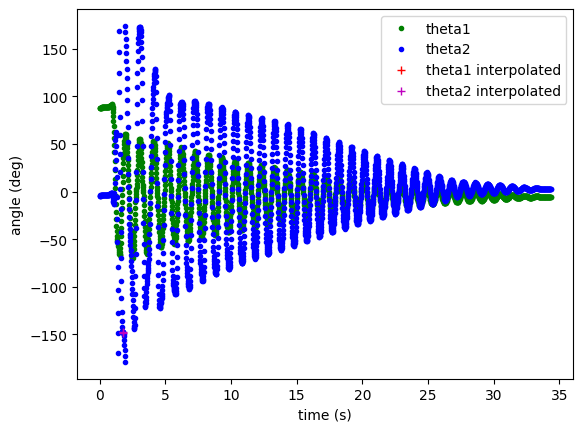

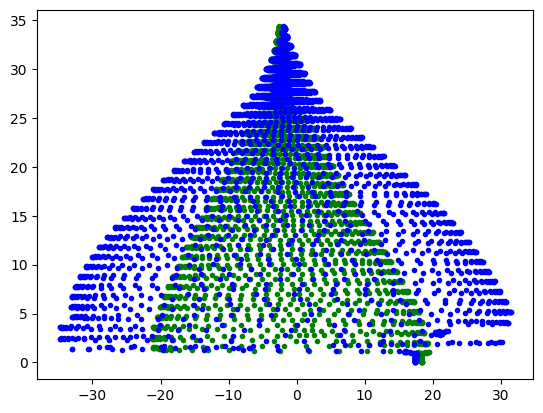

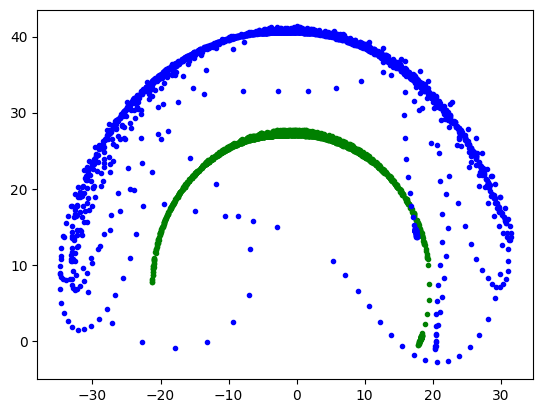

In [197]:
coords= pd.read_csv("Meetdag2_Vid16_total.csv")
x_pix_g = coords["Gx"] -pivot_x
y_pix_g = coords["Gy"] -pivot_y
x_pix_b = coords["Bx"] -pivot_x
y_pix_b = coords["By"] -pivot_y
tijd = coords["time_s"]
x_m_g = x_pix_g /pixels_per_cm
y_m_g = y_pix_g /pixels_per_cm
x_m_b = x_pix_b/pixels_per_cm
y_m_b = y_pix_b/pixels_per_cm

theta_1_full = coords["theta1_deg_filled"]
theta_2_full = coords["theta2_rel_deg_filled"]
theta_1_interpolated = np.where(coords["theta1_interpolated"], coords["theta1_deg_filled"], np.nan)
theta_2_interpolated = np.where(coords["theta2_rel_interpolated"], coords["theta2_rel_deg_filled"], np.nan)
count_1_interpolated = np.count_nonzero(coords["theta1_interpolated"])
count_2_interpolated = np.count_nonzero(coords["theta2_rel_interpolated"])

print(count_1_interpolated)
print(count_2_interpolated)

plt.figure()
plt.plot(tijd, theta_1_full, "g.", label="theta1")
plt.plot(tijd, theta_2_full, "b.", label="theta2")
plt.plot(tijd, theta_1_interpolated, "r+", label="theta1 interpolated")
plt.plot(tijd, theta_2_interpolated, "m+", label="theta2 interpolated")
plt.xlabel("time (s)"); plt.ylabel("angle (deg)"); plt.legend();
plt.show()


plt.figure()
plt.plot(x_m_g,tijd,"g.")
plt.plot(x_m_b,tijd,"b.")
plt.show()

plt.figure()
plt.plot(x_m_g,y_m_g,"g.")
plt.plot(x_m_b,y_m_b,"b.")
plt.show()

Notes meetdag2 
- video 1/2 is wss dezelfde -> veel motion blur
- Video 3 tracked tape aan zijkant tijdens motion blur 
- Video 4 niet bruikbaar -> hij tracked tape aan de zijkant en laptopscherm 
- Video 5 en 6 is ook niet bruikbaar
- motion blur is een probleem -> shutterspeed omhoog kijken of dat iets doen
- Video 10 twijfelbaar